In [ ]:
#1 Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
#Cell 2 — Load Dataset
df = pd.read_csv("/content/loan_approval_dataset.csv")

In [ ]:
#Cell 3 — Display First 5 Rows

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
#Cell 4 — Check Shape
df.shape

(4269, 13)

In [ ]:
#Cell 5 — Check Columns
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [ ]:
#Cell 6 — Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
#Cell 7 — Check Missing Values
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [ ]:
#Cell 8 — Remove Extra Spaces from Column Names
df.columns = df.columns.str.strip()

df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [ ]:
#Cell 9 — Check Loan Status
print(df["loan_status"].value_counts())

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [ ]:
#Cell 10 — Convert Loan Status into Numerical Form
df["loan_status"] = df["loan_status"].str.strip().str.lower()

df["loan_status"] = df["loan_status"].map({
    "approved": 1,
    "rejected": 0
})

print(df["loan_status"].value_counts())

loan_status
1    2656
0    1613
Name: count, dtype: int64


In [ ]:
#Cell 10 — Convert Loan Status into Numerical Form
df["education"] = df["education"].str.strip().str.lower()

df["education"] = df["education"].map({
    "graduate": 1,
    "not graduate": 0
})

In [ ]:
#
df["self_employed"] = df["self_employed"].str.strip().str.lower()

df["self_employed"] = df["self_employed"].map({
    "yes": 1,
    "no": 0
})

In [ ]:
X = df[
    [
        "no_of_dependents",
        "education",
        "self_employed",
        "income_annum",
        "loan_amount",
        "loan_term",
        "cibil_score",
        "residential_assets_value",
        "commercial_assets_value"
    ]
]

y = df["loan_status"]

In [ ]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value
0,2,1,0,9600000,29900000,12,778,2400000,17600000
1,0,0,1,4100000,12200000,8,417,2700000,2200000
2,3,1,0,9100000,29700000,20,506,7100000,4500000
3,3,1,0,8200000,30700000,8,467,18200000,3300000
4,5,0,1,9800000,24200000,20,382,12400000,8200000


In [ ]:
y.head()

,loan_status
0,1
1,0
2,0
3,0
4,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
print("Intercept:", model.intercept_)

Intercept: [1.72656246]


In [ ]:
print("Coefficients:", model.coef_)

Coefficients: [[-0.07647684  0.06825858  0.01896553 -1.31685513  1.31881724 -0.85593898
   4.08631531  0.03154945  0.0928705 ]]


In [ ]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

print(coefficients)

                    feature  coefficient
0          no_of_dependents    -0.076477
1                 education     0.068259
2             self_employed     0.018966
3              income_annum    -1.316855
4               loan_amount     1.318817
5                 loan_term    -0.855939
6               cibil_score     4.086315
7  residential_assets_value     0.031549
8   commercial_assets_value     0.092870


In [ ]:
y_pred = model.predict(X_test_scaled)

print(y_pred)

[1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1
 0 1 0 0 1 0 1 1 1 1 0 0 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 0 1 1 0 1 1 1 0 1 1
 1 0 1 1 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 1 1 0 1 1 1 0 1 0 1 1 0
 0 0 1 1 0 0 1 0 0 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1
 0 1 1 1 1 0 1 1 0 1 0 1 0 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 0 1 0 1 0 0 0 1 1 0 0 1 1 0 0 0 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 1 1 0 1
 1 1 0 1 0 1 1 1 0 1 1 1 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 1 0 0 1 0 1 0 1
 0 0 1 1 0 1 0 0 1 0 1 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 1 1 0 1 1 1 1 0 1 0 0
 0 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 0 1 1 1 1 1 0
 0 0 1 1 1 1 1 1 1 0 0 0 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1
 1 0 0 0 1 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0
 1 0 1 1 1 1 1 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 0 0 1 1
 1 1 1 1 1 0 1 0 1 1 1 0 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 1 0 0 0 1 0 0 1 0 1
 1 1 1 1 1 0 0 1 0 0 1 0 

In [ ]:
y_probability = model.predict_proba(X_test_scaled)

print(y_probability)

[[0.0072251  0.9927749 ]
 [0.98402033 0.01597967]
 [0.37205529 0.62794471]
 ...
 [0.98703657 0.01296343]
 [0.98273489 0.01726511]
 [0.74740659 0.25259341]]


In [ ]:
approved_probability = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
results = pd.DataFrame({
    "actual_status": y_test.values,
    "predicted_status": y_pred,
    "Approval probability": approved_probability
})

print(results.head(10))

   actual_status  predicted_status  Approval probability
0              0                 1              0.992775
1              0                 0              0.015980
2              0                 1              0.627945
3              1                 1              0.982487
4              1                 1              0.977589
5              1                 1              0.999351
6              1                 1              0.998246
7              0                 0              0.380541
8              1                 1              0.842909
9              0                 0              0.078427


In [ ]:
results["Approval probability(%)"] = (
    results["Approval probability"] * 100
)

print(results.head(10))

   actual_status  predicted_status  Approval probability  \
0              0                 1              0.992775   
1              0                 0              0.015980   
2              0                 1              0.627945   
3              1                 1              0.982487   
4              1                 1              0.977589   
5              1                 1              0.999351   
6              1                 1              0.998246   
7              0                 0              0.380541   
8              1                 1              0.842909   
9              0                 0              0.078427   

   Approval probability(%)  
0                99.277490  
1                 1.597967  
2                62.794471  
3                98.248748  
4                97.758901  
5                99.935090  
6                99.824639  
7                38.054063  
8                84.290913  
9                 7.842687  


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy(%):", accuracy * 100)

Accuracy: 0.914519906323185
Accuracy(%): 91.4519906323185


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[278  45]
 [ 28 503]]


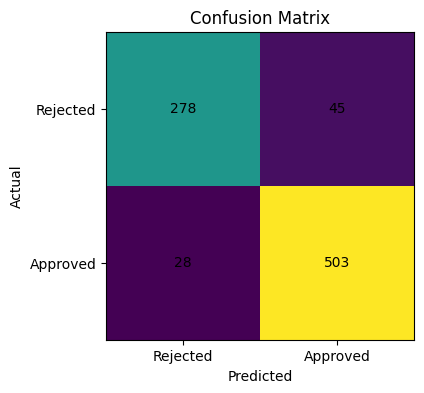

In [ ]:
plt.figure(figsize=(6, 4))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Rejected", "Approved"])
plt.yticks([0, 1], ["Rejected", "Approved"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Rejected", "Approved"]
    )
)

              precision    recall  f1-score   support

    Rejected       0.91      0.86      0.88       323
    Approved       0.92      0.95      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854



In [ ]:
#Cell 32 — New Applicant

'''PDF mein ek new applicant ka example diya gaya hai:

Dependents = 2
Education = Graduate
Self employed = No
Income = 8,000,000
Loan amount = 2,000,000
Loan term = 10 years
CIBIL = 750
Residential assets = 5,000,000
Commercial assets = 2,000,000'''

'PDF mein ek new applicant ka example diya gaya hai:\n\nDependents = 2\nEducation = Graduate\nSelf employed = No\nIncome = 8,000,000\nLoan amount = 2,000,000\nLoan term = 10 years\nCIBIL = 750\nResidential assets = 5,000,000\nCommercial assets = 2,000,000'

In [ ]:
new_applicant = pd.DataFrame({
    "no_of_dependents": [2],
    "education": [1],
    "self_employed": [0],
    "income_annum": [8000000],
    "loan_amount": [2000000],
    "loan_term": [10],
    "cibil_score": [750],
    "residential_assets_value": [5000000],
    "commercial_assets_value": [2000000]
})

In [ ]:
#Cell 33 — Scale New Applicant
new_applicant_scaled = scaler.transform(new_applicant)

In [ ]:
#Cell 34 — Prediction
prediction = model.predict(new_applicant_scaled)

print("Prediction:", prediction)

Prediction: [1]


In [ ]:
#Cell 35 — Approval Probability
probability = model.predict_proba(new_applicant_scaled)

print("Approval probability:", probability * 100)

Approval probability: [[11.00116526 88.99883474]]


In [ ]:
#Cell 36 — Final Decision
if probability[0][1] >= 0.5:
    print("Loan status: Approved")
else:
    print("Loan status: Rejected")

Loan status: Approved


In [ ]:
#Cell 37 — Complete Flow
'''Loan Dataset
      ↓
Data Cleaning
      ↓
Categorical Encoding
      ↓
Select Features
      ↓
X and Y
      ↓
Train-Test Split
      ↓
Feature Scaling
      ↓
Logistic Regression
      ↓
Model Learns Coefficients
      ↓
Linear Equation
      ↓
Sigmoid Function
      ↓
Probability
      ↓
Threshold = 0.5
      ↓
Approved / Rejected
      ↓
Accuracy + Confusion Matrix'''

'Loan Dataset\n      ↓\nData Cleaning\n      ↓\nCategorical Encoding\n      ↓\nSelect Features\n      ↓\nX and Y\n      ↓\nTrain-Test Split\n      ↓\nFeature Scaling\n      ↓\nLogistic Regression\n      ↓\nModel Learns Coefficients\n      ↓\nLinear Equation\n      ↓\nSigmoid Function\n      ↓\nProbability\n      ↓\nThreshold = 0.5\n      ↓\nApproved / Rejected\n      ↓\nAccuracy + Confusion Matrix'